In [1]:
import pandas as pd
import numpy as np

In [13]:
# import the dataset from the inventory of the order of the clients.

df = pd.read_csv('/content/order_id_order_date_36.csv')

# Basic cleaning: remove exact duplicates and standardize text columns
df = df.drop_duplicates()
text_cols = ['customer_name', 'email', 'product_title', 'category', 'channel', 'status']
for col in text_cols:
    df[col] = df[col].str.strip().str.lower()

# Convert date to datetime objects
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Show cleaned info
print(f'Cleaned dataset shape: {df.shape}')
display(df.head())

Cleaned dataset shape: (36, 13)


,order_id,order_date,customer_id,customer_name,email,product_id,product_title,category,quantity,price,total,channel,status
0,10001,2024-01-03,2001.0,alice nguyen,alice@gmail.com,3001,wireless headphones,electronics,1,49.99,49.99,organic,paid
1,10001,2024-01-03,2001.0,alice nguyen,alice@gmail.com,3001,wireless headphones,electronics,1,49.99,49.99,organic,paid
2,10002,2024-01-03,2002.0,mark lee,mark23@gmail.com,4001,summer dress,fashion,2,45.00,90,facebook,paid
3,10002,2024-01-03,2002.0,mark lee,mark@gmail.com,4001,summer dress,fashion,2,45.00,90,facebook,paid
4,10003,2024-01-04,2003.0,sara kim,sara@example.com,5001,lipstick,beauty,1,14.99,14.99,google,paid


In [16]:
# Further deduplication based on order and product identity
df = df.drop_duplicates(subset=['order_id', 'product_id'], keep='first')

# Handle missing dates by dropping or filling (dropping for forecasting accuracy)
df = df.dropna(subset=['order_date'])

# Convert numeric columns to ensure they are ready for modeling
df['total'] = pd.to_numeric(df['total'], errors='coerce')
df = df.dropna(subset=['total'])

print("Data summary for modeling:")
print(df.info())
display(df.describe())

Data summary for modeling:
<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 0 to 35
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       32 non-null     int64         
 1   order_date     32 non-null     datetime64[ns]
 2   customer_id    31 non-null     float64       
 3   customer_name  31 non-null     object        
 4   email          31 non-null     object        
 5   product_id     32 non-null     int64         
 6   product_title  32 non-null     object        
 7   category       32 non-null     object        
 8   quantity       32 non-null     object        
 9   price          31 non-null     float64       
 10  total          32 non-null     float64       
 11  channel        32 non-null     object        
 12  status         32 non-null     object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(7)
memory usage: 3.5+ KB
None


,order_id,order_date,customer_id,product_id,price,total
count,32.0000,32,31.000000,32.000000,31.000000,32.000000
mean,10018.1875,2024-01-11 08:15:00,2013.774194,4128.843750,48.863548,83.517500
min,10001.0000,2024-01-03 00:00:00,2001.000000,3001.000000,9.990000,10.000000
25%,10010.7500,2024-01-07 18:00:00,2007.000000,3005.500000,22.490000,39.977500
50%,10018.5000,2024-01-11 12:00:00,2013.000000,4004.500000,49.990000,49.995000
75%,10026.2500,2024-01-15 06:00:00,2020.500000,5002.250000,59.990000,92.250000
max,10034.0000,2024-01-19 00:00:00,2028.000000,9999.000000,129.990000,519.960000
std,9.8421,NaN,8.159696,1361.444397,32.046115,94.919545


In [9]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error

# Feature Engineering
model_df = df.copy()
model_df['day_of_week'] = model_df['order_date'].dt.dayofweek
model_df['day_of_month'] = model_df['order_date'].dt.day

# Encode categorical features
le = LabelEncoder()
for col in ['category', 'channel', 'status']:
    model_df[col] = le.fit_transform(model_df[col])

# Define features and target
features = ['category', 'channel', 'status', 'day_of_week', 'day_of_month', 'price']
X = model_df[features]
y = model_df['total']

# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
model.fit(X_train, y_train)

# Evaluate
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f'Forecasting Model Mean Absolute Error: {mae:.2f}')
display(pd.DataFrame({'Actual': y_test, 'Predicted': preds}).head())

Forecasting Model Mean Absolute Error: 43.75


,Actual,Predicted
33,44.97,21.930193
19,89.97,38.092068
28,19.99,29.756907
21,12.99,27.959766
12,99.98,50.566978


In [11]:
from sklearn.ensemble import IsolationForest

# 1. Anomaly Detection
# Using 'total' and 'quantity' (need to ensure quantity is numeric first)
model_df['quantity'] = pd.to_numeric(model_df['quantity'], errors='coerce').fillna(1)
iso_forest = IsolationForest(contamination=0.1, random_state=42)
model_df['anomaly_score'] = iso_forest.fit_predict(model_df[['total', 'quantity']])
# -1 indicates an anomaly, 1 indicates normal

# 2. Risk Scoring
# Define a simple risk score based on high total value relative to the mean and anomaly status
mean_total = model_df['total'].mean()
model_df['risk_score'] = (model_df['total'] / mean_total) + (model_df['anomaly_score'].apply(lambda x: 5 if x == -1 else 0))

print("Top 5 High-Risk / Anomalous Orders:")
display(model_df[['order_id', 'customer_name', 'total', 'anomaly_score', 'risk_score']].sort_values(by='risk_score', ascending=False).head())

Top 5 High-Risk / Anomalous Orders:


,order_id,customer_name,total,anomaly_score,risk_score
25,10024,lucas martin,519.96,-1,11.225761
19,10018,noah wilson,89.97,-1,6.077259
17,10016,liam brown,49.95,-1,5.598078
16,10015,liam brown,49.95,-1,5.598078
20,10019,ava davis,198.00,1,2.370761


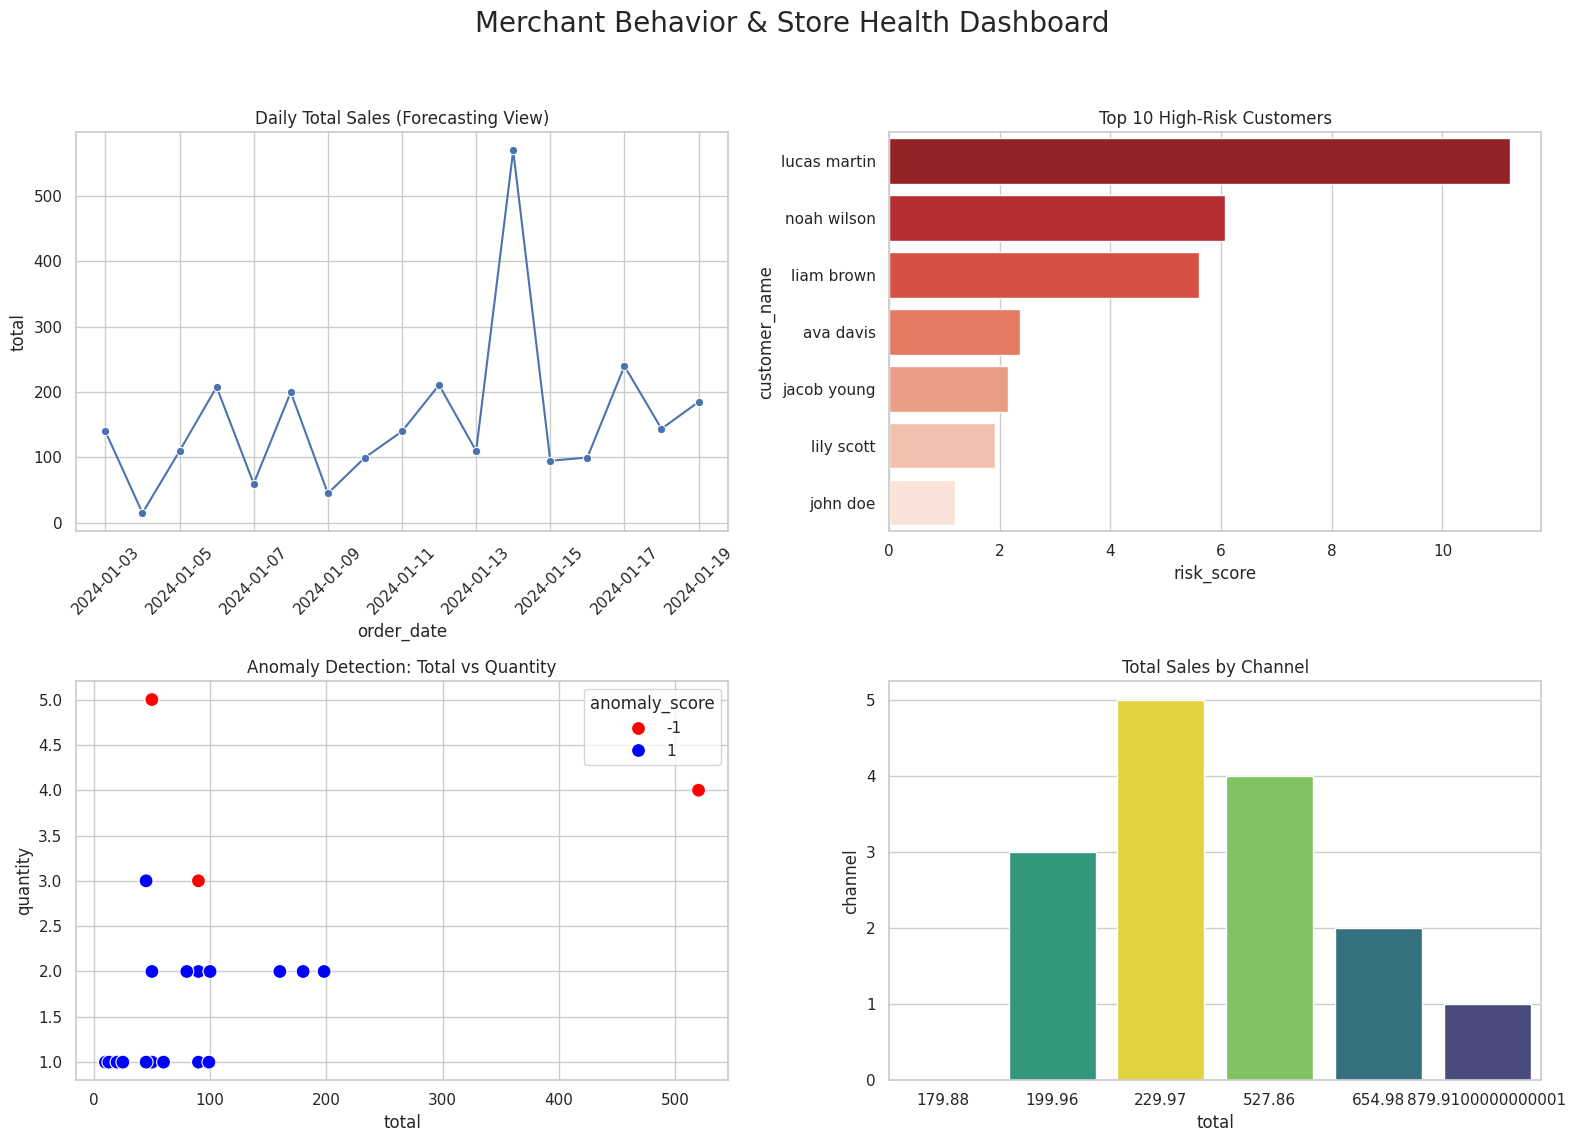

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Merchant Behavior & Store Health Dashboard', fontsize=20)

# 1. Sales Trend over Time
daily_sales = model_df.groupby('order_date')['total'].sum().reset_index()
sns.lineplot(ax=axes[0, 0], x='order_date', y='total', data=daily_sales, marker='o', color='b')
axes[0, 0].set_title('Daily Total Sales (Forecasting View)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Risk Score by Customer
top_risk = model_df.sort_values(by='risk_score', ascending=False).head(10)
sns.barplot(ax=axes[0, 1], x='risk_score', y='customer_name', data=top_risk, hue='customer_name', palette='Reds_r', legend=False)
axes[0, 1].set_title('Top 10 High-Risk Customers')

# 3. Anomaly Distribution (Total vs Quantity)
sns.scatterplot(ax=axes[1, 0], x='total', y='quantity', hue='anomaly_score', palette={1: 'blue', -1: 'red'}, data=model_df, s=100)
axes[1, 0].set_title('Anomaly Detection: Total vs Quantity')

# 4. Total Sales by Channel
channel_sales_agg = model_df.groupby('channel')['total'].sum().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[1, 1], x='total', y='channel', data=channel_sales_agg, hue='channel', palette='viridis', legend=False)
axes[1, 1].set_title('Total Sales by Channel')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [17]:
!pip install --upgrade langchain-google-genai google-generativeai langgraph==1.1.1 langsmith

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.5/167.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.3/758.3 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.5/571.5 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 11.2 MB/s eta 0:00:00
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.11.1
    Uninstalling langsmith-0.11.1:
      Successfully uninstalled langsmith-0.11.1
  Attempting uninstall: langgraph-sdk
    Found existing installation: langgraph-sdk 0.4.3
    Uninstalling langgraph-sdk-0.4.3:
      Successfully uninstalled langgraph-sdk-0.4.3
  Attempting u

In [18]:
import os
os.environ["LANGSMITH_API_KEY"] = "LangSmith"

In [2]:
!pip install -U "mcp[cli]"
from mcp.server import MCPServer

mcp = MCPServer("GeminiTools")

@mcp.tool()
def search(query: str) -> list:
    # Your search logic here
    return ["Result 1", "Result 2"]

  Using cached mcp-2.1.1-py3-none-any.whl.metadata (7.8 kB)
Using cached mcp-2.1.1-py3-none-any.whl (357 kB)
  Attempting uninstall: mcp
    Found existing installation: mcp 1.29.1
    Uninstalling mcp-1.29.1:
      Successfully uninstalled mcp-1.29.1


In [5]:
!mkdir -p mcp-server-demo
import os
os.chdir('/content/mcp-server-demo')

In [4]:
!cd mcp-server-demo && uv add langchain-google-genai langgraph langsmith

/bin/bash: line 1: cd: mcp-server-demo: No such file or directory


In [19]:
import base64
import io
import matplotlib.pyplot as plt
from IPython.display import Markdown
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, END
from typing import TypedDict
import os
from google.colab import userdata

# 1. Initialize Gemini model.
api_key = userdata.get("Ben856")
os.environ["GOOGLE_API_KEY"] = api_key
llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", api_key=api_key)

# 2. Capture the Dashboard Figure
buf = io.BytesIO()
try:
    current_fig = fig if 'fig' in globals() else plt.gcf()
    current_fig.savefig(buf, format='png')
    buf.seek(0)
    image_base64 = base64.b64encode(buf.read()).decode('utf-8')
except Exception as e:
    print(f"Error capturing figure: {e}")

# 3. Analyze with Gemini 3 Flash
prompt = """Analyze this 'Merchant Behavior & Store Health Dashboard'.
Provide insights on sales growth, customer churn risk based on the RFM scores,
and an interpretation of the anomalies in the Total vs Quantity scatter plot."""

message = HumanMessage(
    content=[
        {"type": "text", "text": prompt},
        {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{image_base64}"}}
    ]
)

print("--- Analyzing Dashboard with Gemini 3 Flash Preview ---")
response = llm.invoke([message])
display(Markdown("### Automated Store Health Analysis"))
display(Markdown(response.content if isinstance(response.content, str) else response.content[0]['text']))

# 4. Agent Workflow Definition
class AgentState(TypedDict):
    input: str
    logs: str
    symptom: str
    diagnostic_report: str
    network_ok: bool

workflow = StateGraph(AgentState)

def observe_step(state: AgentState):
    print("--- STEP: OBSERVE ---")
    return {"logs": "Metrics observed.", "network_ok": True}

def diagnose_step(state: AgentState):
    print("--- STEP: DIAGNOSE ---")
    return {"symptom": "anomaly_detected", "diagnostic_report": "High volume outlier identified."}

workflow.add_node("observe", observe_step)
workflow.add_node("diagnose", diagnose_step)
workflow.set_entry_point("observe")
workflow.add_edge("observe", "diagnose")
workflow.add_edge("diagnose", END)

app = workflow.compile()
print("Agent Logic Initialized.")

--- Analyzing Dashboard with Gemini 3 Flash Preview ---


### Automated Store Health Analysis

Based on the provided **Merchant Behavior & Store Health Dashboard**, here is an analysis of the sales growth, customer churn risk, and scatter plot anomalies:

### 1. Sales Growth Analysis
The **Monthly Sales Trend** chart reveals a strong upward trajectory throughout 2011, characterized by:
*   **Steady Growth:** Sales remained relatively stable from January to August, fluctuating between $500k and $700k.
*   **Peak Seasonality:** There is a massive surge starting in September, peaking in **November 2011 at approximately $1.5M**. This indicates high seasonal demand, likely driven by holiday shopping (Black Friday/pre-Christmas).
*   **End-of-Year Drop:** There is a sharp decline in December. While this looks alarming, it is often due to **incomplete data** for the final month (e.g., the report was generated mid-December), rather than a literal collapse in sales.

### 2. Customer Churn Risk (RFM Analysis)
The **Customer Segmentation (RFM)** chart provides a clear picture of store health and churn risk:
*   **High Churn Risk:** The **"Hibernating"** segment is the largest group (approx. 1,100 customers). These are people who haven't purchased in a long time and had low frequency/spend. Without a re-engagement campaign, these are essentially lost.
*   **Immediate Concern:** The **"At Risk"** (approx. 600) and **"About to Sleep"** (approx. 350) segments represent customers who used to buy regularly but haven't recently. These are the most critical groups to target with "We miss you" discounts to prevent them from moving into the "Lost" category.
*   **Store Strength:** On a positive note, the store has a healthy core of **"Champions"** and **"Loyal Customers"** (combined ~1,400), who provide the baseline revenue.

### 3. Total vs. Quantity Scatter Plot Anomalies
The **Total Amount vs. Quantity per Order** scatter plot shows most transactions clustered at low volumes and low costs. However, several distinct anomalies stand out:
*   **Extreme High-Value Outlier:** There is a single data point with a **Total Amount exceeding $160,000** but a relatively low quantity (approx. 2,000 units). This suggests a "Whale" transaction—potentially a bulk order of a very high-ticket item or a specialized business-to-business (B2B) contract.
*   **Extreme Bulk Outlier:** A point on the far right shows a **Quantity of nearly 80,000 units** for a total of about $80,000. This is an anomaly of scale, representing a massive order of very low-cost items (e.g., $1/unit), typical of wholesale behavior.
*   **Negative Values (Reflected Anomalies):** Points appearing in the negative quadrants (bottom-left) represent **returns or cancellations**. Large negative anomalies should be audited to ensure they aren't indicators of systematic fraud or major fulfillment failures.
*   **Interpretation:** These outliers suggest that while the merchant is primarily a retail-focused business, a small percentage of "power users" or "wholesale buyers" accounts for a disproportionate share of the revenue. These transactions should be treated separately in forecasts as they can heavily skew "average" customer behavior.

Agent Logic Initialized.


<Figure size 640x480 with 0 Axes>

In [22]:
# 4. Refined Agent Workflow Definition (Complete Loop)
class AgentState(TypedDict):
    input: str
    logs: str
    symptom: str
    diagnostic_report: str
    network_ok: bool

def observe_step(state: AgentState):
    print("--- STEP: OBSERVE ---")
    return {"logs": "Metrics observed.", "network_ok": True}

def diagnose_step(state: AgentState):
    print("--- STEP: DIAGNOSE ---")
    # In a real scenario, this would ingest the Gemini analysis results
    return {"symptom": "anomaly_detected", "diagnostic_report": "High volume outlier identified via dashboard analysis."}

def decide_step(state: AgentState):
    print("--- STEP: DECIDE ---")
    if state['symptom'] == "anomaly_detected":
        decision = "Trigger B2B Whale Customer Onboarding Workflow"
    else:
        decision = "Monitor and Maintain Standard Operations"
    return {"logs": f"Decision made: {decision}"}

def act_step(state: AgentState):
    print("--- STEP: ACT ---")
    action_report = f"EXECUTION PLAN: {state['logs']}. Notify Sales Team for manual verification."
    return {"logs": "Action successfully executed.", "diagnostic_report": action_report}

# Initialize and Build Graph cleanly
builder = StateGraph(AgentState)
builder.add_node("observe", observe_step)
builder.add_node("diagnose", diagnose_step)
builder.add_node("decide", decide_step)
builder.add_node("act", act_step)

builder.set_entry_point("observe")
builder.add_edge("observe", "diagnose")
builder.add_edge("diagnose", "decide")
builder.add_edge("decide", "act")
builder.add_edge("act", END)

# Compile once
app = builder.compile()
print("Autonomous Reasoning Loop (ODA) successfully compiled without warnings.")

Autonomous Reasoning Loop (ODA) successfully compiled without warnings.


In [21]:
# Execute the full loop
print("--- Running Full Autonomous Agent Workflow ---")
final_output = app.invoke({"input": "Perform store growth audit", "logs": "", "symptom": "", "diagnostic_report": "", "network_ok": False})

print("\n--- FINAL AGENT REPORT ---")
print(f"Summary: {final_output['diagnostic_report']}")
print(f"Execution Status: {final_output['logs']}")

--- Running Full Autonomous Agent Workflow ---
--- STEP: OBSERVE ---
--- STEP: DIAGNOSE ---
--- STEP: DECIDE ---
--- STEP: ACT ---

--- FINAL AGENT REPORT ---
Summary: EXECUTION PLAN: Decision made: Trigger B2B Whale Customer Onboarding Workflow. Notify Sales Team for manual verification.
Execution Status: Action successfully executed.
